# Determine phase speed of GWs from consecutive AMTM measurements
This notebook illustrates the application of the cross wavelet transform (XWT) in two dimensions to consecutive AMTM emasurements in order to determine the phase speed of wave structures.

In [1]:
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('../scripts')
import utils_2d as two

import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

### Load the AMTM data
This test data set contains band intensities from 10 time steps at Río Grande from the night of 16th May 2018.

In [2]:
data_path = '../data/AMTM_RG_20180516.nc'
ds = xr.open_dataset(data_path)

### Preprocessing
For this quick example, let's choose 3 time steps, remove the large-scale background and apply tapering to reduce edge effects.

In [3]:
BI = ds["band intensity"].isel(time=slice(0,3))
nmask  = BI.shape
ntap   = int(0.1*np.min(nmask[0:2]))
signal = np.zeros_like(BI.values)

for t in range(BI['time'].size):
    BI_high, BI_low = two.BG_removal(BI.isel(time=t).values,max_order=1)
    signal[:,:,t]   = utils.smooth_edges(BI_high, ntap, window='tukey')

### 2D-CWT
Perform 2D Wavelet Transform and see if we choose a good range of scales.

In [4]:
dx = BI['x'].values[1]-BI['x'].values[0]
dy = BI['y'].values[1]-BI['y'].values[0]
nx, ny, nt = BI['x'].size, BI['y'].size, BI['time'].size

s0 = 2 #smallest scale that we wanna resolve
s1 = 0.5 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 8
js = int(1/dj*np.log2(s1/s0))
jt = 21
print('Decomposition shape will be: ', js, jt, nx, ny)

result = transform.decompose2d(signal[:,:,0],dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 2*np.pi},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx:.2f} km and the smallest wavelength you analyze is {result['period'][0]:.2f} km.")
print(f"The data domain is at least {min([nx,ny])*dx:.0f} km and the largest wavelength you analyze is {result['period'][-1]:.0f} km.")

Decomposition shape will be:  45 21 213 243
The data resolution is 0.63 km and the smallest wavelength you analyze is 1.25 km.
The data domain is at least 134 km and the largest wavelength you analyze is 57 km.


### First look
We use analyse2d_dominant() to extract the dominant spectral properties for each location (x,y).

In [7]:
domi = utils.analyse2d_dominant(result)

/home/r/Robert.Reichert/juwavelet/juwavelet/utils.py:282: RuntimeWarning: divide by zero encountered in scalar divide
  wy = period / (aspect * np.sin(theta))


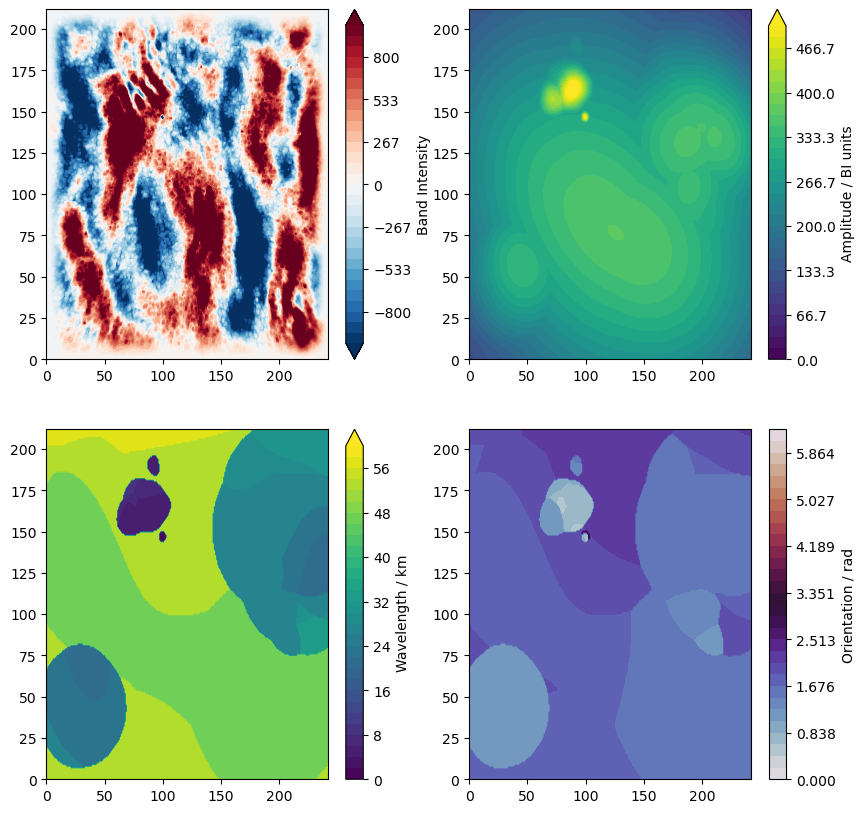

In [18]:
fig=plt.figure(figsize=(10,10))

ax1 = fig.add_subplot(221)
plot_signal = ax1.contourf(signal[:,:,2],levels=np.linspace(-1e3,1e3,31),cmap='RdBu_r',extend='both')
cbar = fig.colorbar(plot_signal,label="Band Intensity")

ax2 = fig.add_subplot(222)
plot_amp = ax2.contourf(domi['coefficient'],levels=np.linspace(0,500,31),extend='max')
cbar = fig.colorbar(plot_amp,label="Amplitude / BI units")

ax3 = fig.add_subplot(223)
plot_lh = ax3.contourf(domi['period'],levels=np.linspace(0,60,31),extend='max')
cbar = fig.colorbar(plot_lh,label='Wavelength / km')

ax4 = fig.add_subplot(224)
plot_th = ax4.contourf(domi['theta'],levels=np.linspace(0,2*np.pi,31),cmap='twilight')
cbar = fig.colorbar(plot_th,label='Orientation / rad')

Text(0.5, 1.0, '$t_2-t_0$')

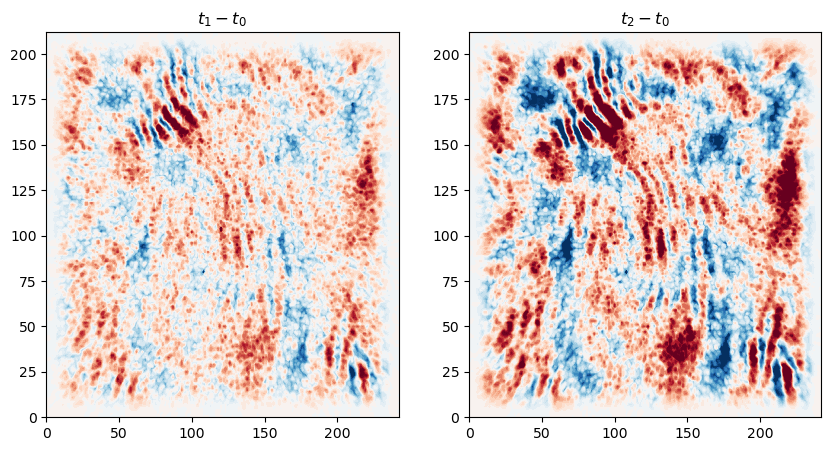

In [24]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax1.contourf(signal[:,:,1]-signal[:,:,0],levels=np.linspace(-1000,1000,31),cmap='RdBu_r',extend='both')
ax1.set_title('$t_1-t_0$')

ax2 = fig.add_subplot(122)
ax2.contourf(signal[:,:,2]-signal[:,:,0],levels=np.linspace(-1000,1000,31),cmap='RdBu_r',extend='both')
ax2.set_title('$t_2-t_0$')

### 2D-XWT
We see that structures are moving as time progresses. In order to determine the phase shift from one time step to the next, we first compute the 2D-CWT for every time step and then the cross wavelet transform (XWT) between those time steps.

In [5]:
shape = result['decomposition'].shape + (nt,)
cwt_result_real = np.zeros(shape)
cwt_result_imag = np.zeros(shape)
XWT_real = np.zeros(shape)
XWT_imag = np.zeros(shape)

for t in range(nt):
    print(f"{t/nt*100:.0f}%")
    cwt_result = transform.decompose2d(signal[:,:,t],dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1, nxpad=None,nypad=None,opts={'param': 2*np.pi}, mode="scaled",dtype=np.complex128)
    cwt_result_real[:,:,:,:,t] = np.real(cwt_result['decomposition'])
    cwt_result_imag[:,:,:,:,t] = np.imag(cwt_result['decomposition'])

for t in range(nt-1):
    print(f"{t/(nt-1)*100:.0f}%")
    XWT_real[:,:,:,:,t] = cwt_result_real[:,:,:,:,t]*cwt_result_real[:,:,:,:,t+1]+cwt_result_imag[:,:,:,:,t]*cwt_result_imag[:,:,:,:,t+1]  
    XWT_imag[:,:,:,:,t] = cwt_result_imag[:,:,:,:,t]*cwt_result_real[:,:,:,:,t+1]-cwt_result_real[:,:,:,:,t]*cwt_result_imag[:,:,:,:,t+1]

xwt_ds = xr.Dataset(
    {
        "xwt_real": xr.DataArray(
            XWT_real,
            dims=("period", "theta", "x", "y", "time"),
            coords={"x": BI['x'].values, "y": BI['y'].values, "time": BI['time'].values, "period": cwt_result['period'], "theta": cwt_result['theta']},
        ),
        "xwt_imag": xr.DataArray(
            XWT_imag,
            dims=("period", "theta", "x", "y", "time"),
            coords={"x": BI['x'].values, "y": BI['y'].values, "time": BI['time'].values, "period": cwt_result['period'], "theta": cwt_result['theta']},
        ),
    },
    attrs={
        'title': '2D Cross Wavelet Transform',
        'instrument_name': 'Advanced Mesospheric Temperature Mapper',
        'location': 'Río Grande',
        'temporal_resolution': 35,
        'horizontal_resolution': 0.625,
        'dj': cwt_result['dj'],
        'js': cwt_result['js'],
        'jt': cwt_result['jt'],
        'dx': cwt_result['dx'],
        'dy': cwt_result['dy'],
        'scale': cwt_result['scale'],
        'aspect': cwt_result['aspect'],
        'mode': cwt_result['mode'],
        'param': cwt_result['opts']['param'],
        'detrending': 'subtraction of 2d linear fit and first harmonic',
        'contact_data_analysis': 'robert.reichert@physik.uni-muenchen.de',
        'contact_raw_data': 'dominiquepautet@gmail.com',
        'references': 'Pautet et al. (2014)',
        'file_creator_name': 'Dr. Robert Reichert',
    },
)

0%
33%
67%
0%
50%


In [15]:
domi2 = utils.analyse2dand1_dominant(xwt_ds)

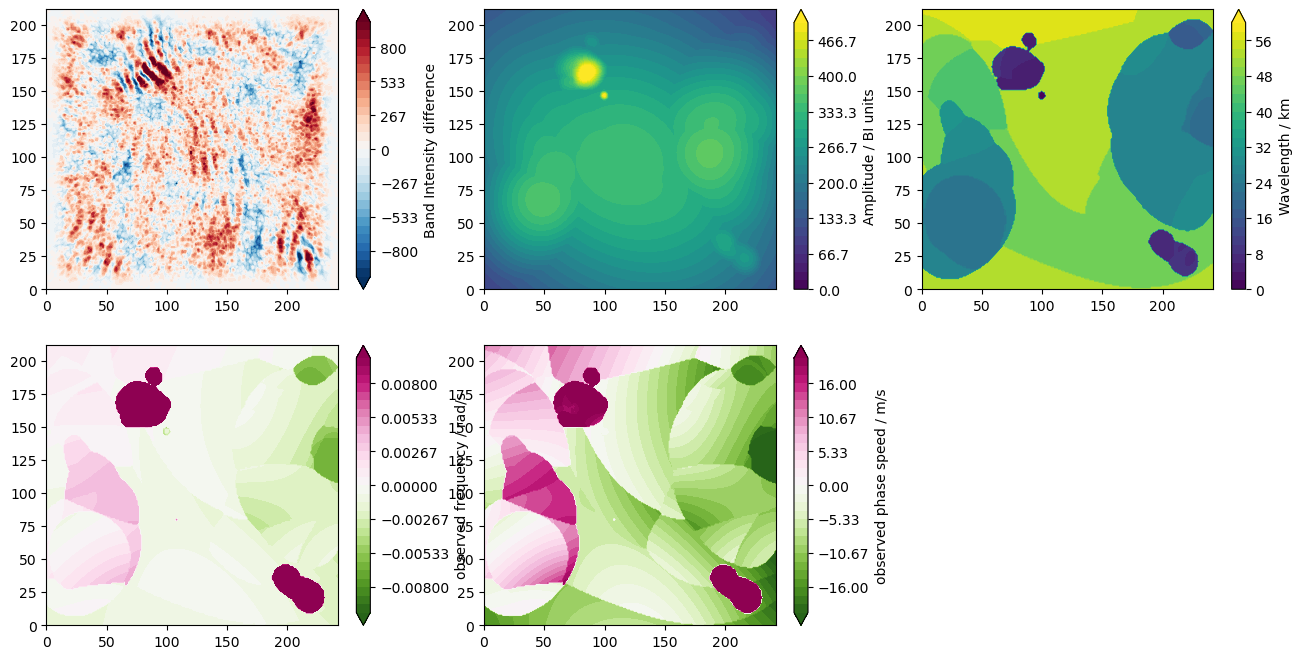

In [33]:
fig=plt.figure(figsize=(16,8))

ax1 = fig.add_subplot(231)
plot_signal = ax1.contourf(signal[:,:,1]-signal[:,:,0],levels=np.linspace(-1e3,1e3,31),cmap='RdBu_r',extend='both')
cbar = fig.colorbar(plot_signal,label="Band Intensity difference")

ax2 = fig.add_subplot(232)
plot_amp = ax2.contourf(np.sqrt(domi2['coefficient'][:,:,0]),levels=np.linspace(0,500,31),extend='max')
cbar = fig.colorbar(plot_amp,label="Amplitude / BI units")

ax3 = fig.add_subplot(233)
plot_lh = ax3.contourf(domi2['period'][:,:,0],levels=np.linspace(0,60,31),extend='max')
cbar = fig.colorbar(plot_lh,label='Wavelength / km')

ax4 = fig.add_subplot(234)
plot_th = ax4.contourf(domi2['phase'][:,:,0]/35,levels=np.linspace(-0.01,0.01,31),cmap='PiYG_r',extend='both')
cbar = fig.colorbar(plot_th,label='observed frequency / rad/s')

ax4 = fig.add_subplot(235)
plot_th = ax4.contourf(domi2['phase'][:,:,0]/35/(2*np.pi/domi2['period'][:,:,0]*1e-3),levels=np.linspace(-20,20,31),cmap='PiYG_r',extend='both')
cbar = fig.colorbar(plot_th,label='observed phase speed / m/s')

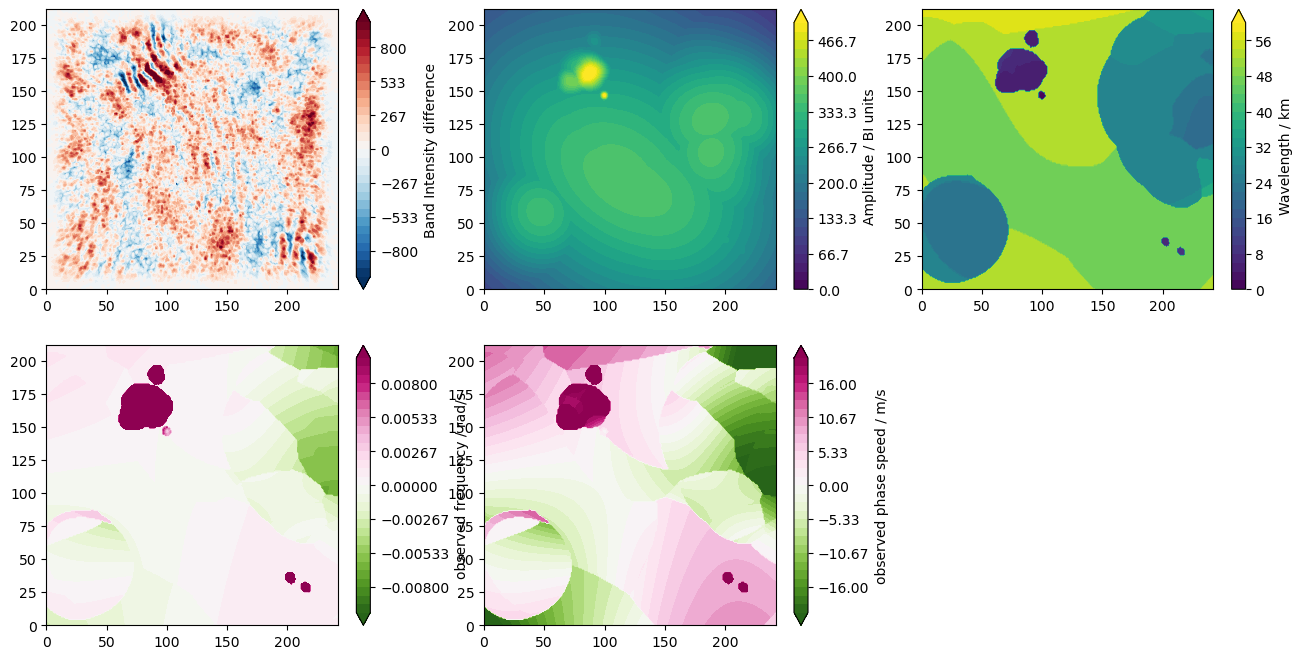

In [34]:
fig=plt.figure(figsize=(16,8))

ax1 = fig.add_subplot(231)
plot_signal = ax1.contourf(signal[:,:,2]-signal[:,:,1],levels=np.linspace(-1e3,1e3,31),cmap='RdBu_r',extend='both')
cbar = fig.colorbar(plot_signal,label="Band Intensity difference")

ax2 = fig.add_subplot(232)
plot_amp = ax2.contourf(np.sqrt(domi2['coefficient'][:,:,1]),levels=np.linspace(0,500,31),extend='max')
cbar = fig.colorbar(plot_amp,label="Amplitude / BI units")

ax3 = fig.add_subplot(233)
plot_lh = ax3.contourf(domi2['period'][:,:,1],levels=np.linspace(0,60,31),extend='max')
cbar = fig.colorbar(plot_lh,label='Wavelength / km')

ax4 = fig.add_subplot(234)
plot_th = ax4.contourf(domi2['phase'][:,:,1]/35,levels=np.linspace(-0.01,0.01,31),cmap='PiYG_r',extend='both')
cbar = fig.colorbar(plot_th,label='observed frequency / rad/s')

ax4 = fig.add_subplot(235)
plot_th = ax4.contourf(domi2['phase'][:,:,1]/35/(2*np.pi/domi2['period'][:,:,1]*1e-3),levels=np.linspace(-20,20,31),cmap='PiYG_r',extend='both')
cbar = fig.colorbar(plot_th,label='observed phase speed / m/s')